# Import the libraries

In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [3]:
path = "training.csv"
df = pd.read_csv(path)
df.shape

(640840, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [5]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [6]:
df.date.head()

0    2013-04-18
1    2015-04-11
2    2013-08-29
3    2013-05-28
4    2013-10-10
Name: date, dtype: object

In [7]:
df.state_holiday.unique()

array(['0', 'a', 'c', 'b'], dtype=object)

In [8]:
df.state_holiday.value_counts()

state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64

The information above show us that the dataset is composed of 640840 rows with 10 features.
8 of those features are integers:
-    `Unnamed: 0`: `ID variable`:`Should be left out of training`, 
-    `store_ID`: `Store identifier, should be left out of training just to keep bias`,
-    `day_of_week`: `Categorical data, 1-7 representing 1 for Sundaym 2 for Monday and so on, should be treated with get_dummies or OHE`,
-    `nb_customers_on_day`: `Number of buying customers on a day, nice numerical data ranging from 0 to 5458, with mean of 633 and std of 464`, 
-    `open`: `Categorical data meaning if the store is open or not, it has 83% of open, no need for dummies`, 
-    `promotion`: `Categorical data meaning if there is a promotion or not, it has 38% of promotion, no need for dummies`, 
-    `school_holiday`:`Categorical data meaning if there is a school holyday, it has 18% of school holidays, no need for dummies`, 
-    `sales`:`The target variable, a numerical value representing the number of sales ranging from 0 to 41551 in a day`.
2 of those are objects:
-    `date`:`Date type in the format yyyy-mm-dd, shall be treated below`,
-    `state_holiday`:`Categorical data representing if there is no holiday represented by 0 and other types of holidays, we should use dummies`.
No row contains null values.

Let's drop Unamed: 0, as this is an ID column. I will also drop Store ID, even though there is a possibility of it mean something for our data, I would like my model to not have this bias.

In [9]:
df = df.drop(['Unnamed: 0', 'store_ID'], axis=1)
df.shape

(640840, 8)

Let's treat the date, basically we will transform 1 date feature into 3 integer features representing day, month and year

In [10]:
df['year'] = pd.to_datetime(df.date).dt.year
df['month'] = pd.to_datetime(df.date).dt.month
df['day'] = pd.to_datetime(df.date).dt.day
print(df.shape) #Sanity check
df = df.drop(['date'], axis=1)
df.shape #Sanity check

(640840, 11)


(640840, 10)

In [11]:
print(df.year.dtype, df.month.dtype, df.day.dtype)

int32 int32 int32


In [12]:
df.school_holiday.value_counts()

school_holiday
0    526468
1    114372
Name: count, dtype: int64

In [13]:
df = pd.get_dummies(df, columns=['day_of_week', 'state_holiday'], drop_first=True, dtype='int32')
df.head()

,nb_customers_on_day,open,promotion,school_holiday,sales,year,month,day,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7,state_holiday_a,state_holiday_b,state_holiday_c
0,517,1,0,0,4422,2013,4,18,0,0,1,0,0,0,0,0,0
1,694,1,0,0,8297,2015,4,11,0,0,0,0,1,0,0,0,0
2,970,1,1,0,9729,2013,8,29,0,0,1,0,0,0,0,0,0
3,473,1,1,0,6513,2013,5,28,1,0,0,0,0,0,0,0,0
4,1068,1,1,0,10882,2013,10,10,0,0,1,0,0,0,0,0,0


Let's see the correlations

<Axes: >

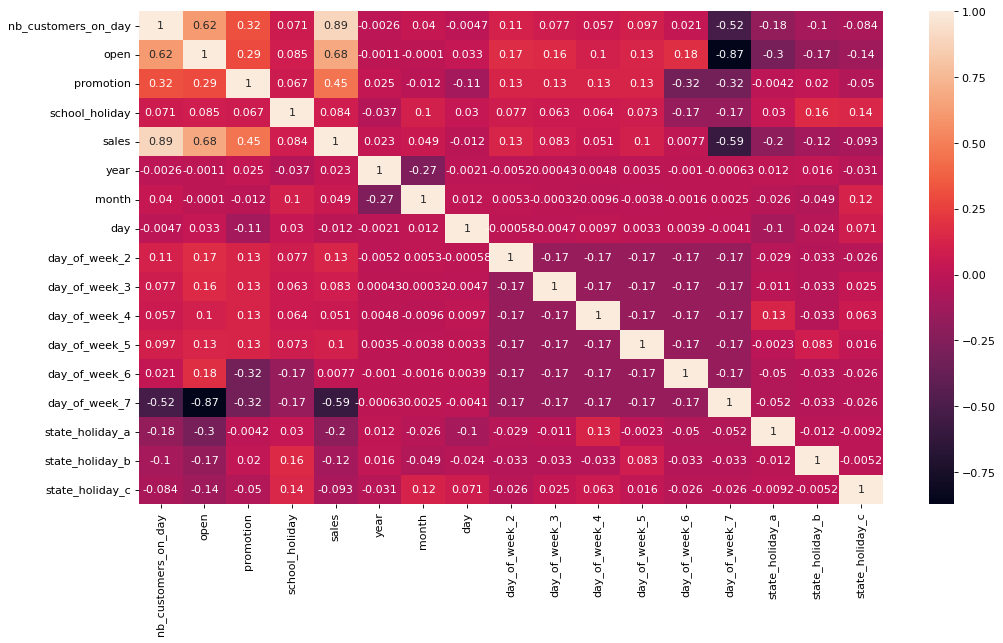

In [14]:
correlations_matrix = df.corr()
plt.figure(figsize=(15,8), dpi=80) 
display(sns.heatmap(correlations_matrix, annot=True))
plt.show()

As there are only 16 features I'll train with all of the variables for now, later I will try to optimize it

In [15]:
df.columns

Index(['nb_customers_on_day', 'open', 'promotion', 'school_holiday', 'sales',
       'year', 'month', 'day', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'day_of_week_7',
       'state_holiday_a', 'state_holiday_b', 'state_holiday_c'],
      dtype='object')

Separating features `X` and target `y`

In [16]:
X = df[['nb_customers_on_day', 'open', 'promotion', 'school_holiday',
       'year', 'month', 'day', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'day_of_week_7',
       'state_holiday_a', 'state_holiday_b', 'state_holiday_c']]
y = df['sales']

In [67]:
y.describe()

count    640840.000000
mean       5777.469011
std        3851.338083
min           0.000000
25%        3731.000000
50%        5746.000000
75%        7860.000000
max       41551.000000
Name: sales, dtype: float64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(480630, 16) (160210, 16) (480630,) (160210,)


Now that we have our target `y` separated of our features `X` and a training test split we can start to train our model. Let's begin using linear regression because it is simple and fast.

### Linear Regression

In [19]:
lin_regressor = LinearRegression().fit(X_train, y_train)
y_hat = lin_regressor.predict(X_test)

r2 = r2_score(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.857035737318024.
mse: 2114772.696132496.
rmse: 1454.2258064456482.
mae: 975.8091377426857.


It's a good starting point, but there is room for improvement, let's see how it deals with cross validation, I will select from our bucket of 6 the minimum r2 score to be conservative

In [41]:
from sklearn.model_selection import cross_validate

cv_results_lin = cross_validate(lin_regressor, X_train, y_train, cv=6, return_train_score=True)

In [28]:
sorted(cv_results_lin.keys())
cv_results_lin['test_score'].min()

0.856151827124518

Let's see how decision tree goes, it has good
explainability power.

### Decision Regression

In [20]:
dt_regressor = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
y_hat = dt_regressor.predict(X_test)

r2 = r2_score(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.7762987214762292.
mse: 3309060.2297188197.
rmse: 1819.08224930013.
mae: 1184.4118476642263.


In [31]:
cv_results_dt = cross_validate(dt_regressor, X_train, y_train, cv=6, return_train_score=True)
sorted(cv_results_dt.keys())
cv_results_dt['test_score'].min()

0.7715197846445373

It has worse r2 than LR, I could try to make it better but let's try random forest due it's immense power.

### Random Forest Regression

In [21]:
rf_regressor = RandomForestRegressor(random_state=42).fit(X_train, y_train)
y_hat = rf_regressor.predict(X_test)

r2 = r2_score(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.8574879138318392.
mse: 2108083.957791112.
rmse: 1451.9242259123278.
mae: 958.8739090506515.


In [32]:
cv_results_rf = cross_validate(rf_regressor, X_train, y_train, cv=6, return_train_score=True)
sorted(cv_results_rf.keys())
cv_results_rf['test_score'].min()

0.8584320102374505

The cross validation score was better than the full training set, perhaps, it removed some unseen bias. Let's try a boosting exactly because of it's power.

### Ada Boosting

In [23]:
ada_regressor = AdaBoostRegressor(random_state=42).fit(X_train, y_train)
y_hat = ada_regressor.predict(X_test)

r2 = r2_score(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.5857355573492133.
mse: 6127930.965833463.
rmse: 2475.4658078498.
mae: 1955.4144968643716.


In [34]:
# Takes too long
# cv_results_ada = cross_validate(ada_regressor, X_train, y_train, cv=6, return_train_score=True)
# sorted(cv_results_ada.keys())
# cv_results_ada['test_score'].min()

It didn't go so well, it's r2 is much lower than DT.

### SVM - TAKES TOO LONG

In [ ]:
# Takes too long
# svm_regressor = LinearSVC(random_state=42, dual='auto').fit(X_train, y_train)
# y_hat = svm_regressor.predict(X_test)

# r2 = r2_score(y_test, y_hat)
# mse = mean_squared_error(y_test, y_hat)
# rmse = root_mean_squared_error(y_test, y_hat)
# mae = mean_absolute_error(y_test, y_hat)

# print(f'r2: {r2}.')
# print(f'mse: {mse}.')
# print(f'rmse: {rmse}.')
# print(f'mae: {mae }.')

### Using Standard Scaler to check if our two better models would receive an upgrade

I will scale only the variable `nb_customers_on_day`, the others are categorical and the target will be left out

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_ss = df[['nb_customers_on_day', 'open', 'promotion', 'school_holiday',
       'year', 'month', 'day', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'day_of_week_7',
       'state_holiday_a', 'state_holiday_b', 'state_holiday_c']]
X_ss['nb_customers_on_day'] = scaler.fit_transform(X_ss[['nb_customers_on_day']]).flatten()
X_ss_train, X_ss_test, y_ss_train, y_ss_test = train_test_split(X_ss, y, test_size=.25, random_state=42)
print(X_ss_train.shape, X_ss_test.shape, y_ss_train.shape, y_ss_test.shape)

(480630, 16) (160210, 16) (480630,) (160210,)


C:\Users\felip\AppData\Local\Temp\ipykernel_17428\3642774228.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ss['nb_customers_on_day'] = scaler.fit_transform(X_ss[['nb_customers_on_day']]).flatten()


In [38]:
X_ss.nb_customers_on_day.describe()

count    6.408400e+05
mean     1.242929e-17
std      1.000001e+00
min     -1.364806e+00
25%     -4.921386e-01
50%     -5.257248e-02
75%      4.408620e-01
max      1.039574e+01
Name: nb_customers_on_day, dtype: float64

In [39]:
lin_regressor_sc = LinearRegression().fit(X_ss_train, y_ss_train)
y_ss_hat = lin_regressor_sc.predict(X_ss_test)

r2 = r2_score(y_ss_test, y_hat)
mse = mean_squared_error(y_ss_test, y_hat)
rmse = root_mean_squared_error(y_ss_test, y_hat)
mae = mean_absolute_error(y_ss_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.5857355573492133.
mse: 6127930.965833463.
rmse: 2475.4658078498.
mae: 1955.4144968643716.


In [40]:
rf_regressor_sc = RandomForestRegressor(random_state=42).fit(X_ss_train, y_ss_train)
y_hat = rf_regressor.predict(X_ss_test)

r2 = r2_score(y_ss_test, y_hat)
mse = mean_squared_error(y_ss_test, y_hat)
rmse = root_mean_squared_error(y_ss_test, y_hat)
mae = mean_absolute_error(y_ss_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: -2.2555197430433487.
mse: 48156680.10419733.
rmse: 6939.501430520591.
mae: 5776.381947443979.


As we can see it is better not to scale the data for our case. Let's focus on our 2 best models, LR and RF.
For LR we can use L1 and L2 regularization. Let's use Elasticnet that is LR with those parameters.
The advantage of it is that it handles correlated features better, performs feature selection by driving some coefficients to zero, and balances bias-variance trade-off.

### Elasticnet

In [44]:
from sklearn.linear_model import ElasticNet

# alpha: the strength of the regularization
# l1_ratio: determines how much weight is given to L1 regularization versus L2 regularization

en_regressor = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42).fit(X_train, y_train)
y_hat = en_regressor.predict(X_test)

r2 = r2_score(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.8512104816066534.
mse: 2200941.72533807.
rmse: 1483.5571190008393.
mae: 988.4345354259419.


Let's tune it a little bit

In [49]:

l1_ratios = [0, 0.1,0.2,0.3,0.4, 0.5,0.6,0.7,0.8, 0.9, 1]
alphas = [0.1, 0.2, 0.3]
r2s = []


for l1_ratio in l1_ratios:
    for alpha in alphas:
        en_regressor_opt = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
        en_regressor_opt.fit(X_train, y_train)
        y_hat = en_regressor_opt.predict(X_test)
        r2 = r2_score(y_test, y_hat)
        r2s.append(r2)
        print(f"alpha={alpha}, l1_ratio={l1_ratio}, r2: {r2:.3f}")

C:\ProgramData\miniforge3\envs\myjlabenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.824e+11, tolerance: 7.136e+08 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


alpha=0.1, l1_ratio=0, r2: 0.847


C:\ProgramData\miniforge3\envs\myjlabenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.131e+11, tolerance: 7.136e+08 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


alpha=0.2, l1_ratio=0, r2: 0.839


C:\ProgramData\miniforge3\envs\myjlabenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.314e+11, tolerance: 7.136e+08 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


alpha=0.3, l1_ratio=0, r2: 0.834
alpha=0.1, l1_ratio=0.1, r2: 0.847
alpha=0.2, l1_ratio=0.1, r2: 0.840
alpha=0.3, l1_ratio=0.1, r2: 0.835
alpha=0.1, l1_ratio=0.2, r2: 0.848
alpha=0.2, l1_ratio=0.2, r2: 0.842
alpha=0.3, l1_ratio=0.2, r2: 0.837
alpha=0.1, l1_ratio=0.3, r2: 0.849
alpha=0.2, l1_ratio=0.3, r2: 0.843
alpha=0.3, l1_ratio=0.3, r2: 0.838
alpha=0.1, l1_ratio=0.4, r2: 0.850
alpha=0.2, l1_ratio=0.4, r2: 0.845
alpha=0.3, l1_ratio=0.4, r2: 0.840
alpha=0.1, l1_ratio=0.5, r2: 0.851
alpha=0.2, l1_ratio=0.5, r2: 0.846
alpha=0.3, l1_ratio=0.5, r2: 0.842
alpha=0.1, l1_ratio=0.6, r2: 0.852
alpha=0.2, l1_ratio=0.6, r2: 0.848
alpha=0.3, l1_ratio=0.6, r2: 0.845
alpha=0.1, l1_ratio=0.7, r2: 0.853
alpha=0.2, l1_ratio=0.7, r2: 0.850
alpha=0.3, l1_ratio=0.7, r2: 0.847
alpha=0.1, l1_ratio=0.8, r2: 0.855
alpha=0.2, l1_ratio=0.8, r2: 0.852
alpha=0.3, l1_ratio=0.8, r2: 0.850
alpha=0.1, l1_ratio=0.9, r2: 0.856
alpha=0.2, l1_ratio=0.9, r2: 0.854
alpha=0.3, l1_ratio=0.9, r2: 0.853
alpha=0.1, l1_ratio=1,

Our better model is for L1_ratio = 1, that means for now that l1 ratio is a bit better then let's use a Lasso model

In [60]:
from sklearn.linear_model import Lasso

la_regressor = Lasso(alpha=0.1, random_state=42).fit(X_train, y_train)
y_hat = la_regressor.predict(X_test)

r2 = r2_score(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
rmse = root_mean_squared_error(y_test, y_hat)
mae = mean_absolute_error(y_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.8570321850890275.
mse: 2114825.241829941.
rmse: 1454.2438728871925.
mae: 975.6947891363434.


In [62]:
alphas=[0.1,0.15, 0.2,0.25,0.3,0.35,0.40,0.45,0.5]
for alpha in alphas:
    la_regressor_opt = Lasso(alpha=alpha)
    la_regressor_opt.fit(X_train, y_train)
    y_hat = la_regressor_opt.predict(X_test)
    r2 = r2_score(y_test, y_hat)
    r2s.append(r2)
    print(f"alpha={alpha}, r2: {r2:.3f}")

alpha=0.1, r2: 0.857
alpha=0.15, r2: 0.857
alpha=0.2, r2: 0.857
alpha=0.25, r2: 0.857
alpha=0.3, r2: 0.857
alpha=0.35, r2: 0.857
alpha=0.4, r2: 0.857
alpha=0.45, r2: 0.857
alpha=0.5, r2: 0.857


It seems we have a plateau. Let's try to tune our RF now. I could create a GridSearch but I won't as I want to tune it manually.

In [71]:
n_estimators = 150 
max_depth = 25
rf_regressor_opt = RandomForestRegressor(n_estimators=n_estimators,random_state=42).fit(X_train, y_train)
y_hat = rf_regressor_opt.predict(X_test)
r2 = r2_score(y_test, y_hat)
print(f'n_estimators={n_estimators}, r2: {r2:.3f}.')

n_estimators=150, r2: 0.858.


In [76]:
n_estimators = 150 
max_depth = 50
rf_regressor_opt = RandomForestRegressor(n_estimators=n_estimators,random_state=42).fit(X_train, y_train)
y_hat = rf_regressor_opt.predict(X_test)
r2 = r2_score(y_test, y_hat)
print(f'n_estimators={n_estimators}, r2: {r2:.3f}.')

n_estimators=150, r2: 0.858.


In [ ]:
n_estimators = 175
max_depth = 50
rf_regressor_opt = RandomForestRegressor(n_estimators=n_estimators,random_state=42).fit(X_train, y_train)
y_hat = rf_regressor_opt.predict(X_test)
r2 = r2_score(y_test, y_hat)
print(f'n_estimators={n_estimators}, r2: {r2:.3f}.')

In [ ]:
cv_results_rf_opt = cross_validate(
                                rf_regressor_opt, 
                                X_train, y_train, 
                                cv=cv, 
                                return_train_score=True)

sorted(cv_results_rf_opt.keys())
cv_results_rf_opt['test_score'].min()

### Training with the `store_ID` feature to see if our model can gain something from knowing the store. And dropping the day column, we already have `day` of the week and the holidays columns.

In [78]:
path = "training.csv"
df_i = pd.read_csv(path)
df_i = df_i.drop(['Unnamed: 0'], axis=1)
df_i['year'] = pd.to_datetime(df_i.date).dt.year
df_i['month'] = pd.to_datetime(df_i.date).dt.month
df_i = df_i.drop(['date'], axis=1)
df_i = pd.get_dummies(df_i, columns=['day_of_week', 'state_holiday'], drop_first=True, dtype='int32')

X_i = df_i[['store_ID','nb_customers_on_day', 'open', 'promotion', 'school_holiday',
       'year', 'month', 'day_of_week_2', 'day_of_week_3',
       'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'day_of_week_7',
       'state_holiday_a', 'state_holiday_b', 'state_holiday_c']]
y_i = df['sales']

X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(X_i, y_i, test_size=.25, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(480630, 16) (160210, 16) (480630,) (160210,)


In [79]:
lin_regressor_i = LinearRegression().fit(X_i_train, y_i_train)
y_hat = lin_regressor_i.predict(X_i_test)

r2 = r2_score(y_i_test, y_hat)
mse = mean_squared_error(y_i_test, y_hat)
rmse = root_mean_squared_error(y_i_test, y_hat)
mae = mean_absolute_error(y_i_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.8571940815270017.
mse: 2112430.418395006.
rmse: 1453.4202483779445.
mae: 975.8974384263661.


In [83]:
y_hat = lin_regressor_i.predict(X_i_train)

In [84]:
r2_train = r2_score(y_i_train, y_training_hat)
mse_train = mean_squared_error(y_i_train, y_training_hat)
rmse_train = root_mean_squared_error(y_i_train, y_training_hat)
mae_train = mean_absolute_error(y_i_train, y_training_hat)

print(f'r2: {r2_train}.')
print(f'mse: {mse_train}.')
print(f'rmse: {rmse_train}.')
print(f'mae: {mae_train}.')

r2: 0.992704195086025.
mse: 108315.4876341036.
rmse: 329.1131836224487.
mae: 200.62094640303673.


### The Winner

In [80]:
rf_regressor_i = RandomForestRegressor(random_state=42).fit(X_i_train, y_i_train)
y_hat = rf_regressor_i.predict(X_i_test)

r2 = r2_score(y_i_test, y_hat)
mse = mean_squared_error(y_i_test, y_hat)
rmse = root_mean_squared_error(y_i_test, y_hat)
mae = mean_absolute_error(y_i_test, y_hat)

print(f'r2: {r2}.')
print(f'mse: {mse}.')
print(f'rmse: {rmse}.')
print(f'mae: {mae }.')

r2: 0.948030531969871.
mse: 768748.8464661144.
rmse: 876.7832380161669.
mae: 536.4307508370215.


In [81]:
y_training_hat = rf_regressor_i.predict(X_i_train)

In [82]:
r2_train = r2_score(y_i_train, y_training_hat)
mse_train = mean_squared_error(y_i_train, y_training_hat)
rmse_train = root_mean_squared_error(y_i_train, y_training_hat)
mae_train = mean_absolute_error(y_i_train, y_training_hat)

print(f'r2: {r2_train}.')
print(f'mse: {mse_train}.')
print(f'rmse: {rmse_train}.')
print(f'mae: {mae_train}.')

r2: 0.992704195086025.
mse: 108315.4876341036.
rmse: 329.1131836224487.
mae: 200.62094640303673.


In [ ]:
with open('SVM.pickle', 'wb') as handle:
    pickle.dump(svm_regressor, handle, protocol=pickle.HIGHEST_PROTOCOL)
file.close()

In [ ]:
from sklearn import datasets
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Create linear SVM with partial_fit
clf = SGDClassifier(loss="hinge", max_iter=1, warm_start=True)

# Simulate epochs with progress bar
epochs = 50
classes = np.unique(y)

for epoch in tqdm(range(epochs), desc="Training Progress"):
    clf.partial_fit(X_train, y_train, classes=classes)

print("Accuracy:", clf.score(X_test, y_test))